<a href="https://colab.research.google.com/github/mdaugherity/MachineLearning2026/blob/main/tutorial/Tutorial_15_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dr. Daugherity, PHYS 453**

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Common Utilities
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.inspection import DecisionBoundaryDisplay

# Classifiers
from sklearn.neural_network import MLPClassifier

# Tutorial 15: NEURAL NETWORKS!

Finally, its time to take over the world.

References:
* User's Guide - http://scikit-learn.org/stable/modules/neural_networks_supervised.html
* API - http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

---
# Simple Example

Load some 2D Iris data that we have used before

In [40]:
X,y = datasets.load_iris(return_X_y=True)
X = X[50:,[2,0]]  # only save features 2 and 0; species 1 and 2
y = y[50:]-1

Training a neural network is easy as $\pi$.  Parameters to adjust:
* **hidden_layer_sizes** : tuple, defaults to (100) so you definitely want to set your own
* **max_iter (default=200)** : crank this up if it isn't converging
* **random_state** : set to a value if you want repeatable results
* **activation{‘identity’, ‘logistic’, ‘tanh’, ‘relu’}, default=’relu’** : logistic is good if everything is between 0 and 1, tanh can be slower but more stable than relu


Read the documentation for more

<Figure size 640x480 with 0 Axes>

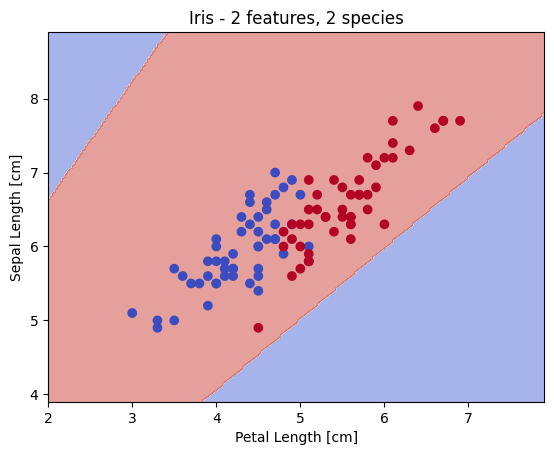

In [46]:
clf = MLPClassifier(hidden_layer_sizes=(5),max_iter=2000, random_state=42)
clf.fit(X,y)

plt.figure()
cmap='coolwarm'
DecisionBoundaryDisplay.from_estimator(clf,X,grid_resolution=200,alpha=0.5,cmap=cmap,response_method='predict')
plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap)
plt.title('Iris - 2 features, 2 species')
plt.xlabel('Petal Length [cm]')
plt.ylabel('Sepal Length [cm]')
plt.show()

In [11]:
clf.score(X,y)

0.5

Aaaaand that failed miserably.  Are you impressed with neural networks yet?  

Well, some of that is our fault.  Like with linear models and several other classifiers **WE NEED TO SCALE THE DATA FIRST!!!!!**.  Neural networks like standardized data, and the easiest way to do that is to use sklearn's StandardScaler to rescale each feature to have a mean of 0 and variance of 1.  

# Standard Scaler

In [12]:
X.mean(axis=0)  # original means of each feature

array([4.906, 6.262])

In [14]:
scaler = StandardScaler()
scaler.fit(X)
print(scaler.mean_)

[4.906 6.262]


In [15]:
X_scale = scaler.transform(X)
X_scale.mean(axis=0)

array([ 3.26960681e-16, -6.68354261e-16])

Like with classifiers, scalers get `fit` to the data.  Then they can `transform` any point.  There is also a combined `fit_transform` method that does both.  Let's see what happens....

<Figure size 640x480 with 0 Axes>

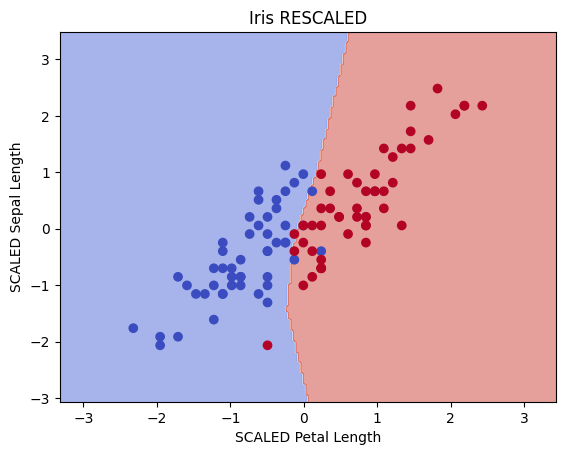

In [44]:
clf = MLPClassifier(hidden_layer_sizes=(5),max_iter=2000, random_state=42)
clf.fit(X_scale,y)

plt.figure()
cmap='coolwarm'
DecisionBoundaryDisplay.from_estimator(clf,X_scale,grid_resolution=200,alpha=0.5,cmap=cmap,response_method='predict')
plt.scatter(X_scale[:,0], X_scale[:,1], c=y, cmap=cmap)
plt.title('Iris RESCALED')
plt.xlabel('SCALED Petal Length')
plt.ylabel('SCALED Sepal Length')
plt.show()

In [28]:
clf.score(X_scale, y)

0.95

One final lesson before the main event.  Remember that neural networks are doing a **search** to find that weights that minimize the loss function.  It is often very helpful to look at the **learning curve** showing how the loss function changes with each iteration.

In [36]:
clf.loss_curve_[-5:]

[np.float64(0.161156564534712),
 np.float64(0.16105892832890695),
 np.float64(0.16096201388803594),
 np.float64(0.1608649758105095),
 np.float64(0.160767851593692)]

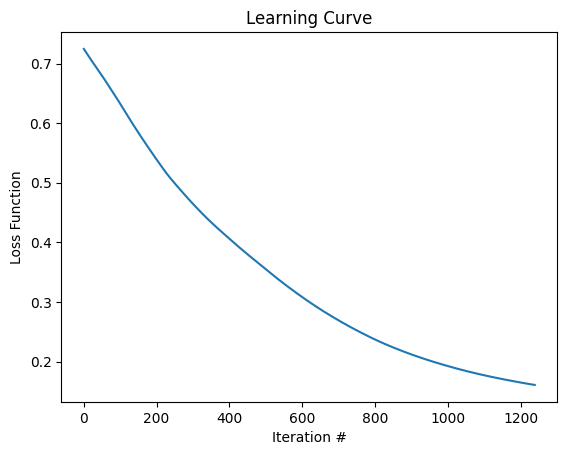

In [37]:
plt.figure()
plt.plot(clf.loss_curve_)
plt.title('Learning Curve')
plt.xlabel('Iteration #')
plt.ylabel('Loss Function')
plt.show()

***
In this example, I will generate and load some datasets to explore what happens when we vary the number of hidden nodes and layers.
Pay attention to how the shape of the decision boundary becomes more complex.

# More Examples



In [38]:
# Generate a few datasets to play with
# have to make some modifications to get 2 classes
Xcircle, ycircle = datasets.make_circles()

num_clust = 20
Xclust,yclust = datasets.make_blobs(n_samples=10*num_clust,centers=num_clust,random_state=42)
yclust = np.floor_divide(yclust,num_clust/2) # default is one class per blob, this changes it to 2 classes

Xmoons, ymoons = datasets.make_moons()

Xblobs, yblobs = datasets.make_blobs(n_samples=100,centers=2,random_state=42,cluster_std=4)

# listify
Xdata = (Xblobs,Xclust,Xmoons,Xcircle)
ydata = (yblobs,yclust,ymoons,ycircle)

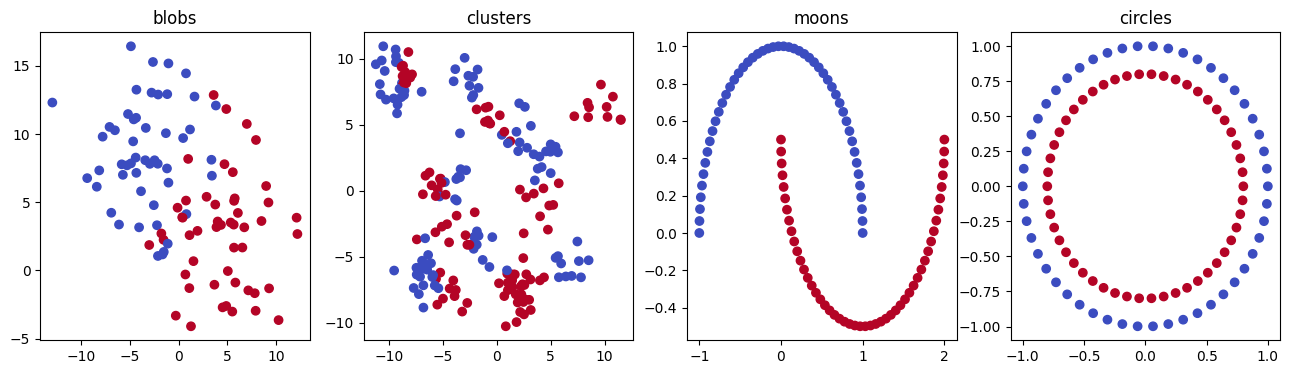

In [39]:
plt.figure(figsize=(16,4))

titles = ('blobs','clusters','moons','circles')
for i,(X,y,title) in enumerate(zip(Xdata,ydata,titles)):
    plt.subplot(1,4,i+1)
    X0 = X[:,0]
    X1 = X[:,1]
    plt.scatter(X0, X1,c=y,cmap='coolwarm')
    plt.title(title)

plt.show()

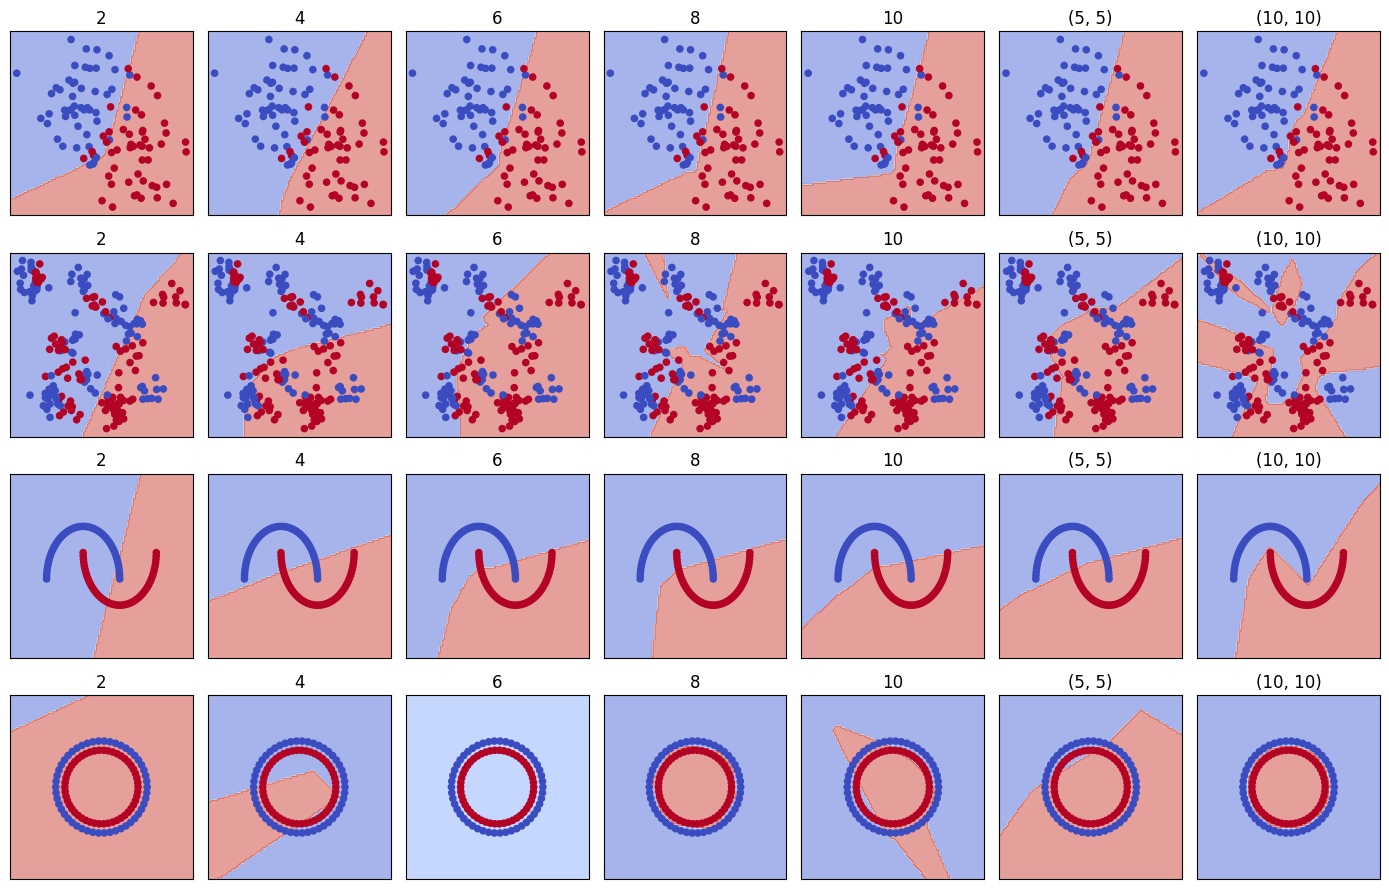

In [48]:
hiddens = ((2),(4),(6),(8),(10),(5,5),(10,10))  # list of hidden layers/nodes to try

plt.figure(figsize=(14,9))
cmap='coolwarm'

for i,(X,y) in enumerate(zip(Xdata,ydata)):
  X0 = X[:,0]
  X1 = X[:,1]

  for j,hidden in enumerate(hiddens):
    ax = plt.subplot(len(Xdata),len(hiddens),len(hiddens)*i+1+j)
    ax.set_title(hidden)
    ax.set_xticks(())
    ax.set_yticks(())
    clf = MLPClassifier(hidden_layer_sizes=hidden,max_iter=10000,random_state=42)
    clf.fit(X,y)

    DecisionBoundaryDisplay.from_estimator(clf,X,grid_resolution=100,ax=ax,alpha=0.5,cmap=cmap,response_method='predict')
    plt.scatter(X0, X1, s=20, c=y,cmap=cmap)

plt.tight_layout()
plt.show()

# Recipe

## Setup
Define helper functions for plotting grid search results:


In [53]:
# These functions visualize results from a parameter grid search.

def make_grid_plot_labels(grid_clf):
  # Turns a parameter dictionary entry into a single string and returns the whole list
  res = grid_clf.cv_results_
  NUM_KEYS = len(res['params'][0].values())
  labels = []
  for item in res['params']:
    labels.append("_".join( [str(val) for val in item.values()]))
  return labels

def make_grid_plot(grid_clf):
  # Displays the scores for every set of parameters
  res = grid_clf.cv_results_
  plt.figure(figsize=(8,4))
  plt.axvline(grid_clf.best_index_, color='black', lw=2) # draw black line behind best params

  NUM_KEYS = len(res['params'])
  x = np.arange(NUM_KEYS)
  plt.plot(res['mean_test_score'],'-o', label='Val')
  plt.fill_between(x,res['mean_test_score']+res['std_test_score'], res['mean_test_score']-res['std_test_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_test_score'],yerr=res['std_test_score'],xerr=0,fmt='-o', capsize=2, label='Val')

  plt.plot(res['mean_train_score'],'-s', label='Train')
  plt.fill_between(x,res['mean_train_score']+res['std_train_score'], res['mean_train_score']-res['std_train_score'], alpha=0.2)
  #plt.errorbar(x, res['mean_train_score'],yerr=res['std_train_score'],xerr=0,fmt='-s', capsize=2,label='Train')
  plt.title('Grid CV Results')
  plt.ylabel('Mean Test Score')

  labels = make_grid_plot_labels(grid_clf)
  plt.xticks(ticks = x, labels=labels, rotation=90)
  plt.legend()
  plt.grid()
  plt.show()

In [50]:
X,y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

## Neural Network Recipe

References:
* User's Guide - http://scikit-learn.org/stable/modules/neural_networks_supervised.html
* API - http://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

Notes:
* Each run starts with **random** weights.  Remove random_state if you want different results every time
* Ideally you will have 5-10 training samples per weight.  So for a single hidden layer the number of features times the number of hidden nodes should not exceed 20% of the number of training samples.  Here we have 4 features and 120 samples,  so we can't expect reliable results for much more than 20 nodes
* Adding parameter options makes the grid search **EXPONENTIALLY** longer.  Start with just hidden nodes to narrow down a range, then add activation function or others
* To suppress warnings add this code above the grid search (make sure to indent):
```
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
```



Grid Parameters: {'clf__hidden_layer_sizes': [4, 6, 8, 10, (2, 2), (3, 3), (4, 4)]}
Best parameters: {'clf__hidden_layer_sizes': (3, 3)}
Best Validation Score:	0.973
Best Train Score:		0.982


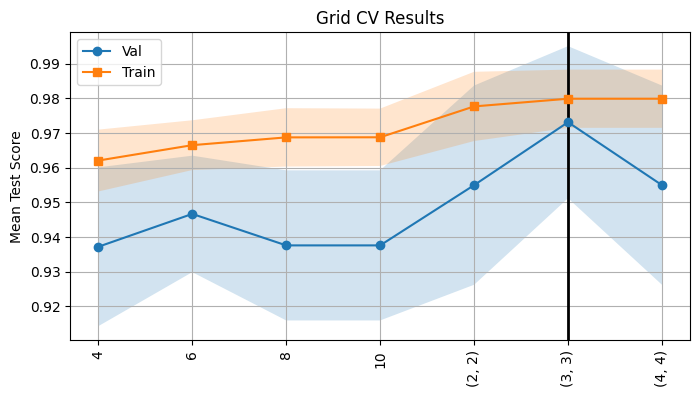

In [56]:
# Define Pipeline
estimators = [('scaler', StandardScaler()), ('clf', MLPClassifier(max_iter=2000, random_state=0)) ]
pipe = Pipeline(estimators)

# Grid Search Parameters
#params = {'clf__hidden_layer_sizes': np.arange(2,10)}   # start with something like this for single layer
params = {'clf__hidden_layer_sizes': [(4),(6),(8),(10),(2,2),(3,3),(4,4)]}   # 2 layer example
#params = {'clf__hidden_layer_sizes': [(5),(10),(3,3),(4,4)],  'clf__activation': ['tanh', 'relu'] } # varying activation functions
print('Grid Parameters:',params)

grid_clf = GridSearchCV(pipe, param_grid=params, return_train_score=True)
grid_clf.fit(X_train, y_train)

print('Best parameters:', grid_clf.best_params_)
print(f"Best Validation Score:\t{grid_clf.best_score_:0.3f}")
print(f"Best Train Score:\t\t{grid_clf.score(X_train,y_train):0.3f}")

make_grid_plot(grid_clf) # Plot the results

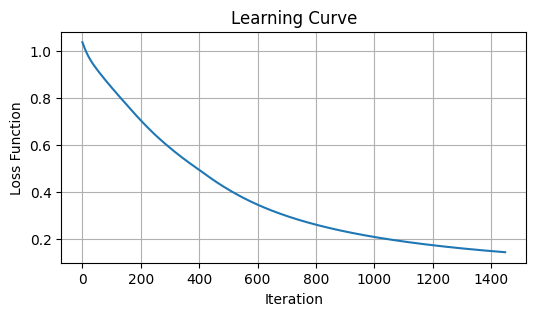

In [57]:
plt.figure(figsize=(6,3))
clf = grid_clf.best_estimator_[-1]
plt.plot(clf.loss_curve_)
plt.ylabel('Loss Function')
plt.xlabel('Iteration')
plt.title('Learning Curve')
plt.grid()
plt.show()